# VisionXplain - Data Exploration

This notebook explores the chest X-ray dataset used for pneumonia classification.

## Dataset Overview
- **Task**: Binary classification (NORMAL vs PNEUMONIA)
- **Split**: 70% train / 15% validation / 15% test
- **Image Size**: 224×224 pixels
- **Format**: JPEG images


In [1]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from collections import Counter
from PIL import Image
import seaborn as sns

# Set style
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

# Project root - find by looking for key project directories
current_dir = Path().resolve()
project_root = None

# Search up the directory tree for project root (has 'src' and 'outputs' directories)
search_dir = current_dir
max_levels = 10
for _ in range(max_levels):
    if (search_dir / "src").exists() and (search_dir / "outputs").exists():
        project_root = search_dir
        break
    if search_dir == search_dir.parent:
        break
    search_dir = search_dir.parent

if project_root is None:
    # Fallback: use current directory
    project_root = current_dir

data_dir = project_root / "data" / "processed" / "chest_xray"

print(f"Current working directory: {current_dir}")
print(f"Project root: {project_root}")
print(f"Data directory: {data_dir}")
print(f"Data directory exists: {data_dir.exists()}")


Current working directory: /Users/benedicthavor-abrahams/Desktop/VisonXplain/projects-Deep-Learning/visionxplain
Project root: /Users/benedicthavor-abrahams/Desktop/VisonXplain/projects-Deep-Learning/visionxplain
Data directory: /Users/benedicthavor-abrahams/Desktop/VisonXplain/projects-Deep-Learning/visionxplain/data/processed/chest_xray
Data directory exists: True


## 1. Dataset Statistics


In [2]:
def count_images_in_split(split_name):
    """Count images in each class for a given split."""
    split_dir = data_dir / split_name
    if not split_dir.exists():
        return {}
    
    counts = {}
    for class_name in ['NORMAL', 'PNEUMONIA']:
        class_dir = split_dir / class_name
        if class_dir.exists():
            counts[class_name] = len(list(class_dir.glob("*.jpeg")) + list(class_dir.glob("*.jpg")))
        else:
            counts[class_name] = 0
    return counts

# Count images in each split
splits = ['train', 'val', 'test']
dataset_stats = {}

for split in splits:
    dataset_stats[split] = count_images_in_split(split)
    print(f"\n{split.upper()} Split:")
    for class_name, count in dataset_stats[split].items():
        print(f"  {class_name}: {count} images")
    print(f"  Total: {sum(dataset_stats[split].values())} images")

# Overall statistics
total_normal = sum([dataset_stats[s]['NORMAL'] for s in splits])
total_pneumonia = sum([dataset_stats[s]['PNEUMONIA'] for s in splits])
total_images = total_normal + total_pneumonia

print(f"\n{'='*50}")
print(f"OVERALL DATASET STATISTICS")
print(f"{'='*50}")
print(f"Total NORMAL images: {total_normal}")
print(f"Total PNEUMONIA images: {total_pneumonia}")
print(f"Total images: {total_images}")
print(f"NORMAL percentage: {100*total_normal/total_images:.2f}%")
print(f"PNEUMONIA percentage: {100*total_pneumonia/total_images:.2f}%")



TRAIN Split:
  NORMAL: 1108 images
  PNEUMONIA: 2991 images
  Total: 4099 images

VAL Split:
  NORMAL: 237 images
  PNEUMONIA: 640 images
  Total: 877 images

TEST Split:
  NORMAL: 238 images
  PNEUMONIA: 642 images
  Total: 880 images

OVERALL DATASET STATISTICS
Total NORMAL images: 1583
Total PNEUMONIA images: 4273
Total images: 5856
NORMAL percentage: 27.03%
PNEUMONIA percentage: 72.97%


## 2. Visualize Class Distribution


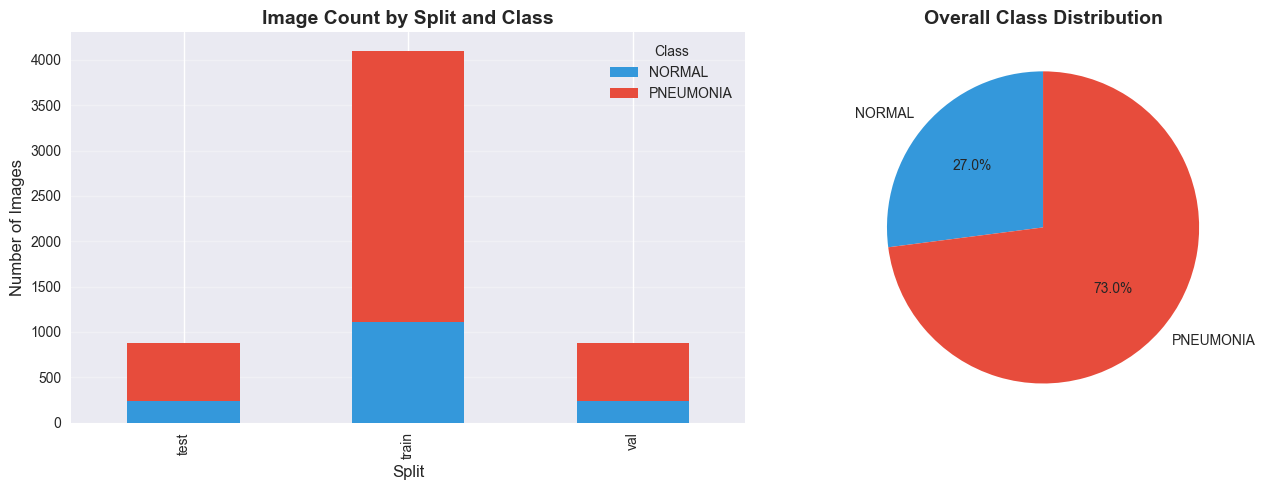

In [3]:
# Create visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar plot by split
splits_list = []
classes_list = []
counts_list = []

for split in splits:
    for class_name in ['NORMAL', 'PNEUMONIA']:
        splits_list.append(split)
        classes_list.append(class_name)
        counts_list.append(dataset_stats[split][class_name])

df = pd.DataFrame({
    'Split': splits_list,
    'Class': classes_list,
    'Count': counts_list
})

# Plot 1: Stacked bar chart
pivot_df = df.pivot(index='Split', columns='Class', values='Count')
pivot_df.plot(kind='bar', stacked=True, ax=axes[0], color=['#3498db', '#e74c3c'])
axes[0].set_title('Image Count by Split and Class', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Split', fontsize=12)
axes[0].set_ylabel('Number of Images', fontsize=12)
axes[0].legend(title='Class')
axes[0].grid(axis='y', alpha=0.3)

# Plot 2: Pie chart for overall distribution
axes[1].pie([total_normal, total_pneumonia], 
            labels=['NORMAL', 'PNEUMONIA'],
            autopct='%1.1f%%',
            colors=['#3498db', '#e74c3c'],
            startangle=90)
axes[1].set_title('Overall Class Distribution', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig(project_root / 'outputs' / 'plots' / 'dataset_distribution.png', dpi=150, bbox_inches='tight')
plt.show()


## 3. Sample Images Visualization


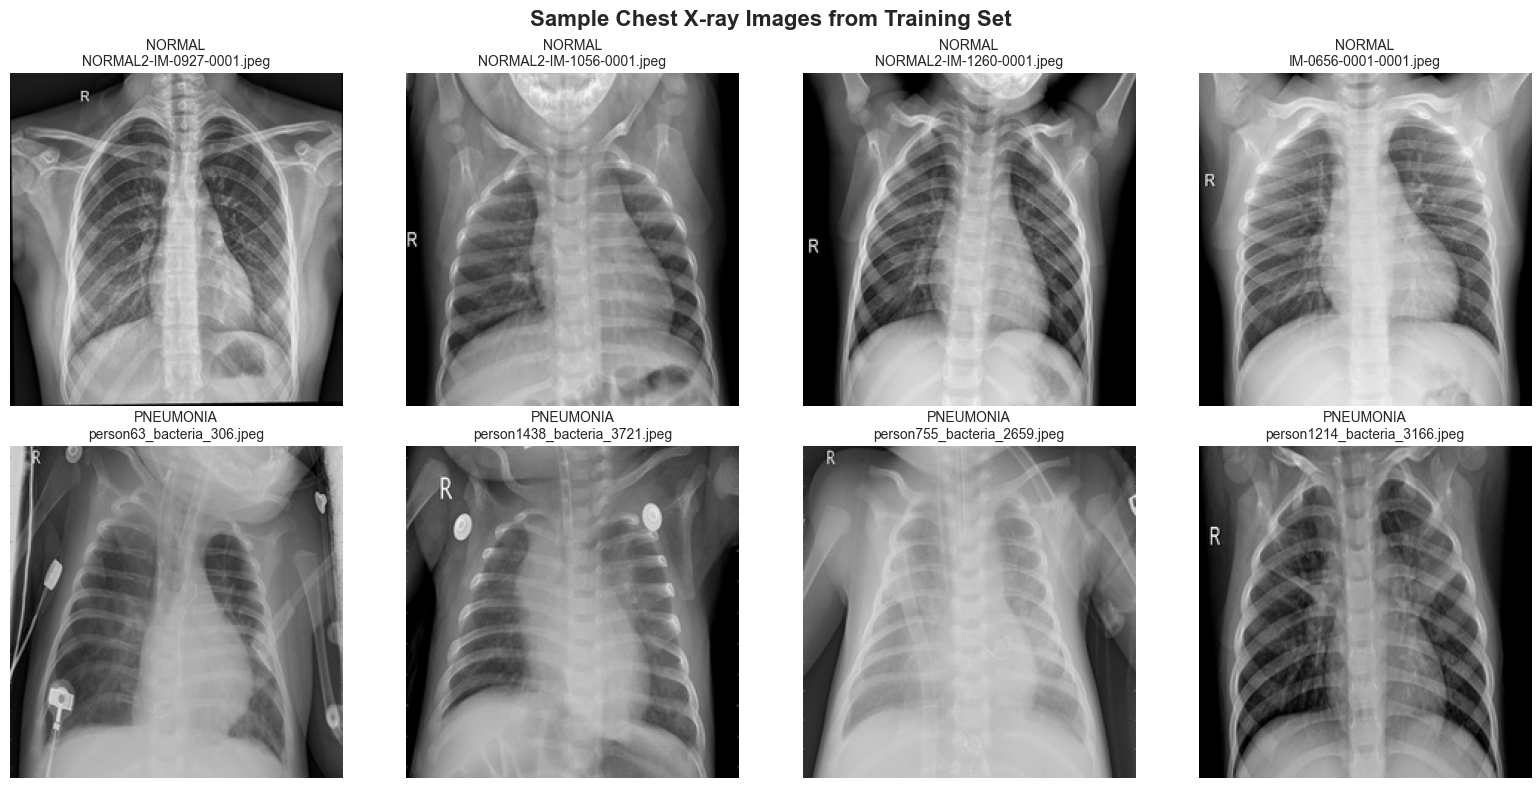

In [4]:
def get_sample_images(split='train', num_samples=4):
    """Get sample images from each class."""
    samples = {}
    for class_name in ['NORMAL', 'PNEUMONIA']:
        class_dir = data_dir / split / class_name
        if class_dir.exists():
            images = list(class_dir.glob("*.jpeg")) + list(class_dir.glob("*.jpg"))
            samples[class_name] = images[:num_samples]
    return samples

# Get sample images
train_samples = get_sample_images('train', num_samples=4)

# Visualize
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle('Sample Chest X-ray Images from Training Set', fontsize=16, fontweight='bold')

for row, class_name in enumerate(['NORMAL', 'PNEUMONIA']):
    for col, img_path in enumerate(train_samples[class_name]):
        img = Image.open(img_path)
        axes[row, col].imshow(img, cmap='gray')
        axes[row, col].set_title(f'{class_name}\n{img_path.name}', fontsize=10)
        axes[row, col].axis('off')

plt.tight_layout()
plt.savefig(project_root / 'outputs' / 'plots' / 'sample_images.png', dpi=150, bbox_inches='tight')
plt.show()


## 4. Image Size Analysis


Analyzing image sizes (sampling first 100 from each class)...

Image Size Statistics:
           width                                                height         \
           count   mean  std    min    25%    50%    75%    max  count   mean   
class                                                                           
NORMAL     100.0  224.0  0.0  224.0  224.0  224.0  224.0  224.0  100.0  224.0   
PNEUMONIA  100.0  224.0  0.0  224.0  224.0  224.0  224.0  224.0  100.0  224.0   

           ...               aspect_ratio                                     
           ...    75%    max        count mean  std  min  25%  50%  75%  max  
class      ...                                                                
NORMAL     ...  224.0  224.0        100.0  1.0  0.0  1.0  1.0  1.0  1.0  1.0  
PNEUMONIA  ...  224.0  224.0        100.0  1.0  0.0  1.0  1.0  1.0  1.0  1.0  

[2 rows x 24 columns]


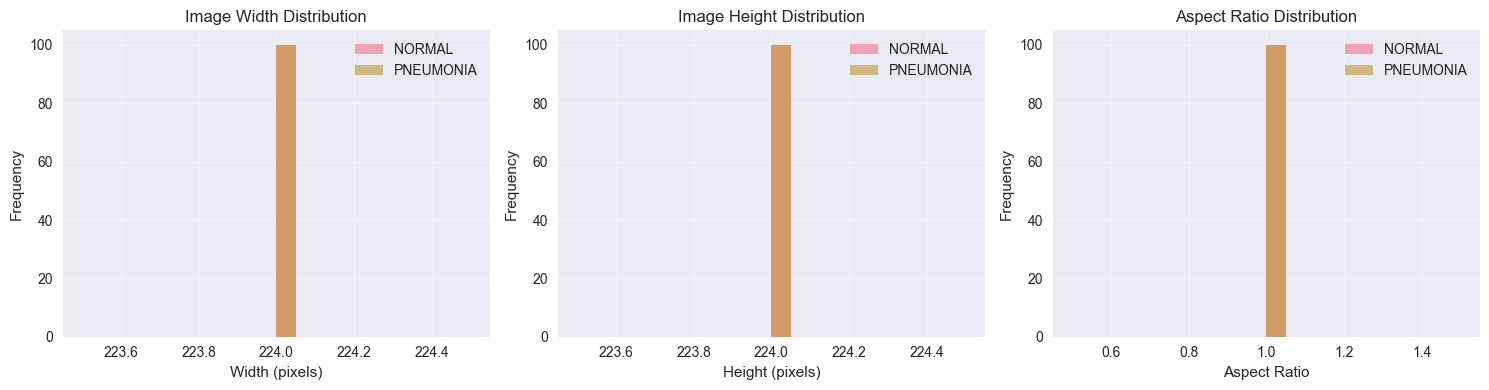

In [5]:
# Sample images to check sizes (check first 100 from each class)
def analyze_image_sizes(split='train', max_samples=100):
    """Analyze image dimensions."""
    sizes = []
    for class_name in ['NORMAL', 'PNEUMONIA']:
        class_dir = data_dir / split / class_name
        if class_dir.exists():
            images = list(class_dir.glob("*.jpeg")) + list(class_dir.glob("*.jpg"))
            for img_path in images[:max_samples]:
                try:
                    img = Image.open(img_path)
                    sizes.append({
                        'class': class_name,
                        'width': img.width,
                        'height': img.height,
                        'aspect_ratio': img.width / img.height
                    })
                except Exception as e:
                    print(f"Error loading {img_path}: {e}")
    return sizes

# Analyze sizes
print("Analyzing image sizes (sampling first 100 from each class)...")
sizes = analyze_image_sizes('train', max_samples=100)

if sizes:
    import pandas as pd
    df_sizes = pd.DataFrame(sizes)
    
    print(f"\nImage Size Statistics:")
    print(df_sizes.groupby('class')[['width', 'height', 'aspect_ratio']].describe())
    
    # Visualize
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    
    # Width distribution
    for class_name in ['NORMAL', 'PNEUMONIA']:
        class_data = df_sizes[df_sizes['class'] == class_name]
        axes[0].hist(class_data['width'], alpha=0.6, label=class_name, bins=20)
    axes[0].set_xlabel('Width (pixels)')
    axes[0].set_ylabel('Frequency')
    axes[0].set_title('Image Width Distribution')
    axes[0].legend()
    axes[0].grid(alpha=0.3)
    
    # Height distribution
    for class_name in ['NORMAL', 'PNEUMONIA']:
        class_data = df_sizes[df_sizes['class'] == class_name]
        axes[1].hist(class_data['height'], alpha=0.6, label=class_name, bins=20)
    axes[1].set_xlabel('Height (pixels)')
    axes[1].set_ylabel('Frequency')
    axes[1].set_title('Image Height Distribution')
    axes[1].legend()
    axes[1].grid(alpha=0.3)
    
    # Aspect ratio distribution
    for class_name in ['NORMAL', 'PNEUMONIA']:
        class_data = df_sizes[df_sizes['class'] == class_name]
        axes[2].hist(class_data['aspect_ratio'], alpha=0.6, label=class_name, bins=20)
    axes[2].set_xlabel('Aspect Ratio')
    axes[2].set_ylabel('Frequency')
    axes[2].set_title('Aspect Ratio Distribution')
    axes[2].legend()
    axes[2].grid(alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(project_root / 'outputs' / 'plots' / 'image_size_analysis.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print("No images found to analyze.")


## Summary

This exploration provides insights into:
- Dataset size and class distribution
- Visual examples of chest X-ray images
- Image characteristics (size, aspect ratio)

**Note**: Images are preprocessed to 224×224 for model training.
